# Hamiltonian Simulation with Quantum Singular Value Transformation (QSVT)

> **Simulating physical and chemical systems** was among the original motivations for quantum computing, as first envisioned by Richard Feynman in 1982, and remains one of its most impactful applications. Time-independent Hamiltonian simulation refers to the task of approximately implementing the unitary evolution operator $e^{-iHt}$ for a Hermitian matrix $H$. When access to the Hamiltonian is provided via block-encoding, this can be realized by applying an appropriate polynomial transformation within a desired precision $\epsilon$.
>
> **Quantum Singular Value Transformation (QSVT)** [<a href="#ref-grand">1</a>] achieves Hamiltonian simulation by exploiting the decomposition $e^{-iHt} = \cos(Ht) - i\sin(Ht)$. Two QSVT blocks, one for the even polynomial $\cos(xt)$ and one for the odd polynomial $\sin(xt)$ (both approximated via the [Jacobi–Anger expansion](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/jacobi_anger_expansion.ipynb), Eqs. (3)-(4)), are combined via LCU. Unlike GQSP and Qubitization, QSVT operates **directly on the block-encoding** without requiring a walk operator or controlled block-encoding calls, using only **two auxiliary qubits**.
>
> - **Input:** A Hermitian operator $H$ given through a block-encoding unitary $U_H$ with scaling factor $\alpha \ge \|H\|$, evolution time $t$, and target error $\epsilon$.
> - **Output:** A unitary $U$ approximating $e^{-iHt}$, with $\|U - e^{-iHt}\| < \epsilon$.
>
> **Complexity:** $O\!\left(\alpha t + \frac{\log \epsilon^{-1}}{\log\!\left(e + \log(\epsilon^{-1}) / \alpha t\right)}\right)$ calls to the block-encoding, using two auxiliary qubits. No controlled block-encoding calls required. Requires classical preprocessing to compute QSVT rotation angles.
>
> ---
>
> **Keywords:** Hamiltonian Simulation, Block Encoding, Quantum Singular Value Transformation, QSVT, Quantum Signal Processing, LCU, Oracle/Query complexity.

A block-encoded Hamiltonian refers to its embedding within a larger unitary matrix.

**Definition**: A $(s, m, \epsilon)$-encoding of a $2^n\times 2^n$ matrix $A$ refers to completing it into a $2^{n+m}\times 2^{n+m}$ unitary matrix $U_{(s,m,\epsilon)-A}$:
$$
U_{(s,m,\epsilon)-A} = \begin{pmatrix}
A/s & * \\
* & *
\end{pmatrix},
$$
with functional error $\left|\left|\left(U_{(s,m,\epsilon)-A}\right)_{0:2^n-1,0:2^n-1}-A/s \right|\right|\leq \epsilon$. Here $s$ is a scaling factor that ensures the overall operator is unitary, $m$ is the number of auxiliary (block) qubits, and $\epsilon$ is the encoding error.

This notebook assumes basic knowledge of Linear Combination of Unitaries (LCU) and the PREPARE–SELECT implementation; see the [LCU tutorial](https://github.com/Classiq/classiq-library/blob/main/tutorials/basic_tutorials/quantum_primitives/linear_combination_of_unitaries/linear_combination_of_unitaries.ipynb) for background.

We assume an exact $(s, m, 0)$-encoding of the Hamiltonian as input. The QSVT method outputs an approximated block-encoding of its time evolution:
$$
U_{(s,m,0)-H} \;\rightarrow\; U_{(2,\,m+2,\,\epsilon)-\exp(-iHt)} = \begin{pmatrix}
\exp(-iHt)/2 & * \\
* & *
\end{pmatrix}.
$$
This is achieved by implementing a block-encoding for the polynomial approximation $P(H)\approx \frac{1}{\tilde{s}}e^{-iHt}$. To recover the exact unitary $e^{-iHt}$ one would apply amplitude amplification to drive the prefactor $1/2\rightarrow 1$; here we instead employ projected statevector simulation.

QSVT is a general method for implementing polynomial singular value transformation of block-encoded matrices, where each polynomial must have a well-defined parity (even or odd). The transformation is based on Quantum Signal Processing (QSP), achieved by a series of qubit rotations. In the case of general polynomial transformation, as in Hamiltonian simulation $e^{-iHt} = \cos(Ht) - i\sin(Ht)$, one can apply two polynomial transformations, one for the even polynomial $\cos(xt)$ and one for the odd polynomial $\sin(xt)$, combined via Linear Combination of Unitaries (LCU). The two QSVT circuits are combined using the `qsvt_lcu` function, which implements an optimized `select` operation that interleaves the rotations of both polynomials within a single QSVT traversal. The overall result is a $(2,\,m+2,\,\epsilon)$-block-encoding of $e^{-iHt}$, 
where one block qubit comes from the QSVT and the second one, as well as the $1/2$ prefactor, originates from the LCU.

(In practice, our prefactor is slightly different, $2\beta^{-1}$ with $\beta = 0.9999$ which ensures numerical stability of the classical angle computation).

**<div class="alert alert-success">This notebook demonstrates Hamiltonian simulation using the QSVT method. For the other approaches, see the companion notebooks on <a href="https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_gqsp.ipynb">GQSP</a> and <a href="https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qubitization.ipynb">Qubitization</a>. For a side-by-side <a href="#Comparison-with-Other-Methods">comparison of all three methods</a>, see the table at the end of this notebook.</div>**

## Preliminaries

### Setting a Specific Hamiltonian to Evolve

We set some specific hyperparameters for our problem. We use a simple Hamiltonian given as a sum of Pauli strings, and the `lcu_pauli` function to block-encode it via the Linear Combination of Unitaries (LCU) technique:
$$
H = \sum_{i} \alpha_i U_i, \qquad U_{(\bar{\alpha},m,0)-H} = \begin{pmatrix} H/\bar{\alpha} & * \\ * & * \end{pmatrix}, \qquad \bar{\alpha} = \sum_i |\alpha_i|.
$$

*To treat different problems with the same algorithm, simply change theses hyperparameters*.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy

from classiq import *

In [2]:
EVOLUTION_TIME = 22
EPS = 1e-7

HAMILTONIAN = (
    0.4 * Pauli.I(0)
    + 0.1 * Pauli.Z(1)
    + 0.05 * Pauli.X(0) * Pauli.X(1)
    + 0.2 * Pauli.Z(0) * Pauli.Z(1)
)
print(f"The Hamiltonian to evolve: {HAMILTONIAN}")

The Hamiltonian to evolve: 0.4 + 0.05*Pauli.X(0)*Pauli.X(1) + 0.2*Pauli.Z(0)*Pauli.Z(1) + 0.1*Pauli.Z(1)


Next, we define the block-encoding quantum function, and a Quantum Struct for its variable

In [3]:
data_size = HAMILTONIAN.num_qubits
block_size = (
    (len(HAMILTONIAN.terms) - 1).bit_length() if len(HAMILTONIAN.terms) != 1 else 1
)
BE_SCALING = np.sum(
    np.abs([term.coefficient for term in HAMILTONIAN.terms])
)  # scaling for LCU of Paulis

print(f"Block size: {block_size}")
print(f"Block-encoding scaling factor: {BE_SCALING}")


class BlockEncodedState(QStruct):
    data: QNum[data_size]
    block: QNum[block_size]


@qfunc
def be_hamiltonian(state: BlockEncodedState):
    lcu_pauli(HAMILTONIAN * (1 / BE_SCALING), state.data, state.block)

Block size: 2
Block-encoding scaling factor: 0.75


Finally, we set the initial state to evolve and calculate classically the expected evolved state for verifying the quantum method.

In [4]:
state_to_evolve = np.random.rand(2**data_size)
state_to_evolve = (state_to_evolve / np.linalg.norm(state_to_evolve)).tolist()
matrix = pauli_operator_to_matrix(HAMILTONIAN)
expected_state = scipy.linalg.expm(-1j * matrix * EVOLUTION_TIME) @ state_to_evolve

### Setting Up a Statevector Simulator

Working with block-encoding typically requires post-selection of the block variable being at state $|0\rangle$. The success of this process can be amplified via Oblivious Amplitude Amplification. In this notebook, instead, we use a statevector simulator and project the result. We import two utility functions from `hamiltonian_simulation_utils`:
- `get_projected_state_vector`: extracts the post-selected statevector from the execution results.
- `compare_quantum_classical_states`: aligns the global phase and computes the overlap with the classically computed reference.

In [5]:
from hamiltonian_simulation_utils import (
    compare_quantum_classical_states,
    get_projected_state_vector,
)

execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)

### The Jacobi–Anger Expansion

The polynomial approximation of the time evolution relies on the [Jacobi–Anger expansion](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/jacobi_anger_expansion.ipynb). For QSVT, we use the real Chebyshev forms $\cos(xt)$ and $\sin(xt)$ (Eqs. (3)–(4)), computed via `poly_jacobi_anger_cos` and `poly_jacobi_anger_sin`. From these, we derive the QSVT rotation angles using `qsvt_phases`.

In [6]:
from classiq.applications.qsp import qsvt_phases
from classiq.applications.qsp.qsp import (
    poly_jacobi_anger_cos,
    poly_jacobi_anger_degree,
    poly_jacobi_anger_sin,
)

t0 = time.perf_counter()

qsvt_degree = poly_jacobi_anger_degree(EPS, EVOLUTION_TIME * BE_SCALING)
COS_SCALE = SIN_SCALE = 0.9999
poly_even = COS_SCALE * poly_jacobi_anger_cos(qsvt_degree, EVOLUTION_TIME * BE_SCALING)
phases_cos = qsvt_phases(poly_even)

poly_odd = SIN_SCALE * poly_jacobi_anger_sin(qsvt_degree, EVOLUTION_TIME * BE_SCALING)
phases_sin = qsvt_phases(poly_odd)

classical_preprocess_time_qsvt = time.perf_counter() - t0
print(f"QSVT polynomial degree: {qsvt_degree}")
print(f"Classical preprocessing time: {classical_preprocess_time_qsvt:.3f} s")

assert np.abs(len(phases_sin) - len(phases_cos)) <= 1

QSVT polynomial degree: 33
Classical preprocessing time: 2.813 s


### Verifying the Block-Encoding

As a sanity check before the main algorithm, we verify the Hamiltonian block-encoding: we apply $U_H$ on the initial state and check that the post-selected result matches $(H/\bar{\alpha})|\psi\rangle$ as expected.

In [7]:
@qfunc
def main(data: Output[QNum[data_size]], block: Output[QNum[block_size]]):
    state = BlockEncodedState()
    allocate(state)

    inplace_prepare_amplitudes(state_to_evolve, 0.0, state.data)
    be_hamiltonian(state)
    bind(state, [data, block])


qprog_be = synthesize(main)
show(qprog_be)

Quantum program link: https://platform.classiq.io/circuit/3CyiPqnAmox223LILYExbE9I4Kg


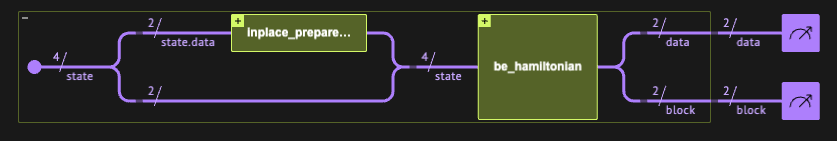

In [8]:
with ExecutionSession(qprog_be, execution_preferences=execution_preferences) as es:
    res_be = es.sample()

state_result_be = get_projected_state_vector(res_be)
expected_state_be = matrix @ state_to_evolve

renormalized_be, overlap_be = compare_quantum_classical_states(
    expected_state_be, state_result_be, BE_SCALING
)
print("Expected state:", expected_state_be)
print("Resulting state after rescaling:", renormalized_be)
assert np.linalg.norm(renormalized_be - expected_state_be) < EPS
print("=" * 40)
print("Overlap between expected and resulting state:", overlap_be)

Expected state: [0.44111175+0.j 0.10298395+0.j 0.08552232+0.j 0.03931935+0.j]
Resulting state after rescaling: [0.44111175+5.54280611e-17j 0.10298395+6.27022155e-17j
 0.08552232-2.11342034e-17j 0.03931935+1.23493892e-17j]
Overlap between expected and resulting state: 1.0000000000000002


## Implementation

We define Quantum Structs for the QSVT block-encoding. Two block qubits are used: one for the QSVT signal processing (`block_qsvt`) and one for the LCU select (`block_lcu`).

The `qsvt_hamiltonian_evolution` function uses `prepare_select` with the `qsvt_lcu` as the select operation. The LCU coefficients $(1/2, -i/2)$ implement $\frac{1}{2}(\cos(Ht) - i\sin(Ht)) = \frac{1}{2}e^{-iHt}$. The `projector_cnot` function implements the QSVT projector onto the $|0\rangle$ state of the Hamiltonian block variable.

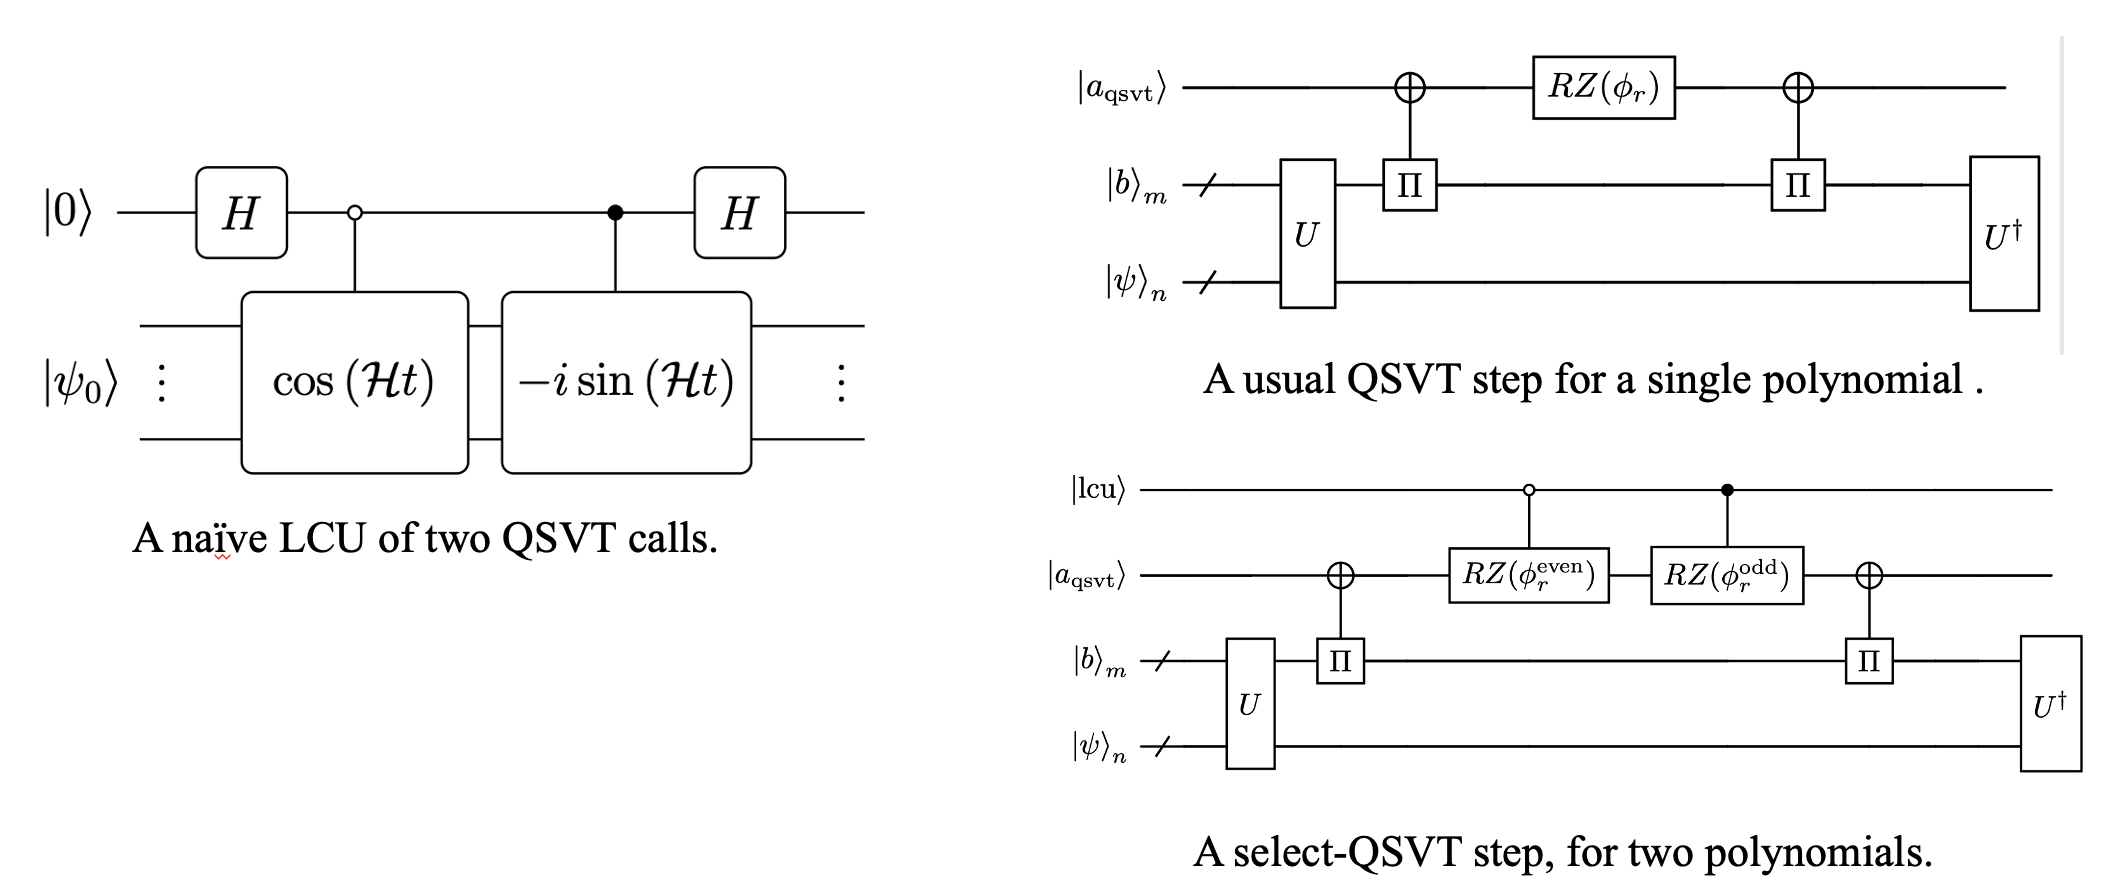
<center> On the left is the naive LCU design for the select of two QSVT calls (taken from Ref. [<a href="#ref-grand">1</a>] ), where each call is applied using a repetition over the usual QSVT step on the upper right panel, where each polynomial is acheived by its own series of angles $\phi_r$. However, one can design an optimized select operation, by selecting the rotations within the QSVT steps themselves, as shown in the lower right panel.</center>

In [9]:
class QSVTBlock(QStruct):
    block_ham: QNum[block_size]
    block_qsvt: QBit
    block_lcu: QBit


class QSVTState(QStruct):
    data: QNum[data_size]
    block: QSVTBlock


@qfunc
def qsvt_hamiltonian_evolution(
    phases_cos: list[float],
    phases_sin: list[float],
    be_qfunc: QCallable[BlockEncodedState],
    state: QSVTState,
):
    def projector_cnot(q: QBit):
        q ^= state.block.block_ham == 0

    prepare_select(
        coefficients=[1 / 2, -1j / 2],
        select=lambda block_lcu: qsvt_lcu(
            phases_cos,
            phases_sin,
            projector_cnot,
            projector_cnot,
            lambda: be_qfunc([state.data, state.block.block_ham]),
            state.block.block_qsvt,
            block_lcu,
        ),
        block=state.block.block_lcu,
    )

The code in the rest of this section builds a model that applies the `qsvt_hamiltonian_evolution` function on the randomly prepared vector $(\vec{\psi},\vec{0})$, synthesizes it, executes the resulting quantum program, and verifies the results. 

In [10]:
@qfunc
def main(data: Output[QNum[data_size]], block: Output[QNum[block_size + 2]]):
    state = QSVTState()
    allocate(state)
    inplace_prepare_amplitudes(state_to_evolve, 0.0, state.data)
    qsvt_hamiltonian_evolution(phases_cos, phases_sin, be_hamiltonian, state)
    bind(state, [data, block])


qprog_qsvt = synthesize(main, constraints=Constraints(optimization_parameter="width"))
show(qprog_qsvt)

Quantum program link: https://platform.classiq.io/circuit/3CyiUc3VZKzBVhLLQ3bkJyTmLwG


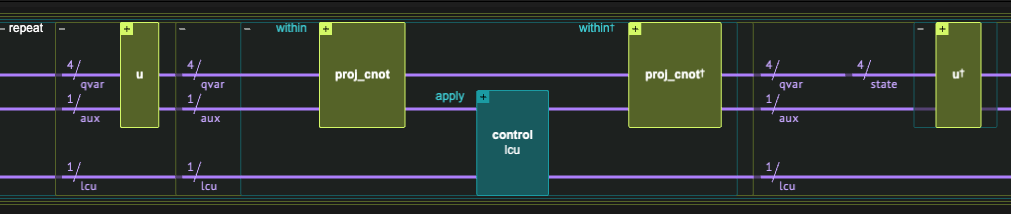

In [11]:
with ExecutionSession(qprog_qsvt, execution_preferences) as es:
    results_qsvt = es.sample()

state_result_qsvt = get_projected_state_vector(results_qsvt)
exp_scaling_factor_qsvt = 2 * (1 / COS_SCALE)

In [12]:
renormalized_state_qsvt, overlap_qsvt = compare_quantum_classical_states(
    expected_state, state_result_qsvt, exp_scaling_factor_qsvt
)
print("Expected state:", expected_state)
print("Resulting state after rescaling:", renormalized_state_qsvt)
assert np.linalg.norm(renormalized_state_qsvt - expected_state) < EPS
print("=" * 40)
print("Overlap between expected and resulting state:", overlap_qsvt)

Expected state: [-0.60614634-2.06208549e-04j  0.36975795-5.92464025e-02j
 -0.16337915-6.61167654e-01j -0.10957163-1.28507370e-01j]
Resulting state after rescaling: [-0.60614634-2.06208549e-04j  0.36975795-5.92464014e-02j
 -0.16337915-6.61167655e-01j -0.10957163-1.28507370e-01j]
Overlap between expected and resulting state: 1.0


## References

<a id='ref-grand'>[1]</a>: [Martyn, J. M., Rossi, Z. M., Tan, A. K., & Chuang, I. L. *Grand unification of quantum algorithms.* PRX Quantum **2**, 040203 (2021).](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.2.040203)

## Technical Notes

### Comparison with Other Methods

| Method | extra block qubits | Controlled $U_H$? | Amplitude amplification? | Classical preprocessing |
|---|---|---|---|---|
| [GQSP](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_gqsp.ipynb) | 1 | Yes | No | Angle computation |
| [QSVT](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qsvt.ipynb) | 2 | No | Yes (for a factor of 2) | Angle computation |
| [Qubitization](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qubitization.ipynb) | $O(\log d)$ | Yes | Yes (for the sum of Cheb. coefficients) | None |

All three methods share the same asymptotic query complexity. Differences in the table reflect the detailed implementation of this specific example.